In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


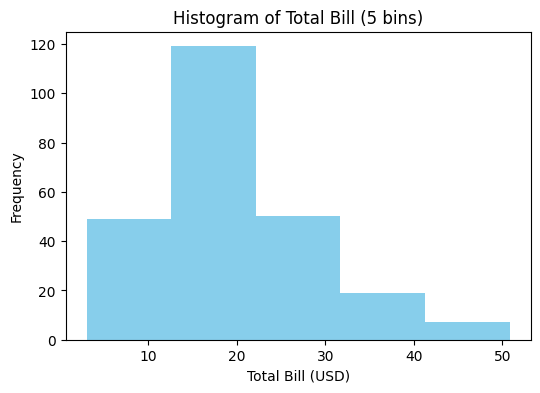

In [2]:
plt.figure(figsize=(6,4))
plt.hist(df['total_bill'], bins=5, color='skyblue')
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Total Bill (5 bins)")
plt.show()

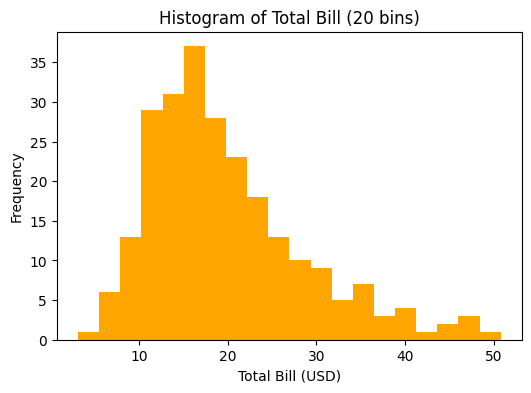

In [3]:
plt.figure(figsize=(6,4))
plt.hist(df['total_bill'], bins=20, color='orange')
plt.xlabel("Total Bill (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Total Bill (20 bins)")
plt.show()

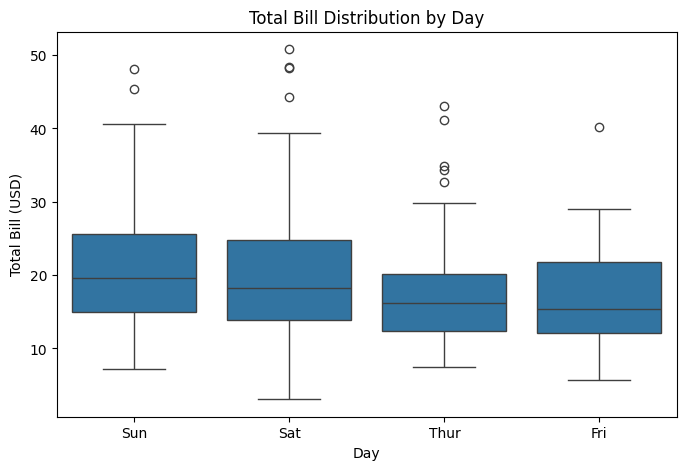

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x='day', y='total_bill', data=df)

plt.xlabel("Day")
plt.ylabel("Total Bill (USD)")
plt.title("Total Bill Distribution by Day")

plt.show()

In [5]:
# Group by day and calculate quartiles
q1 = df.groupby('day')['total_bill'].quantile(0.25)
q3 = df.groupby('day')['total_bill'].quantile(0.75)

iqr = q3 - q1

print("Q1:\n", q1)
print("\nQ3:\n", q3)
print("\nIQR:\n", iqr)

# Example for Saturday
day = 'Sat'
lower_bound = q1[day] - 1.5 * iqr[day]
upper_bound = q3[day] + 1.5 * iqr[day]

print("\nSaturday Bounds:")
print("Lower:", lower_bound)
print("Upper:", upper_bound)

# Outliers
outliers = df[(df['day'] == day) &
              ((df['total_bill'] < lower_bound) |
               (df['total_bill'] > upper_bound))]

print("\nSaturday Outliers:\n", outliers)

Q1:
 day
Fri     12.0950
Sat     13.9050
Sun     14.9875
Thur    12.4425
Name: total_bill, dtype: float64

Q3:
 day
Fri     21.7500
Sat     24.7400
Sun     25.5975
Thur    20.1550
Name: total_bill, dtype: float64

IQR:
 day
Fri      9.6550
Sat     10.8350
Sun     10.6100
Thur     7.7125
Name: total_bill, dtype: float64

Saturday Bounds:
Lower: -2.3475
Upper: 40.99250000000001

Saturday Outliers:
      total_bill    tip     sex smoker  day    time  size
59        48.27   6.73    Male     No  Sat  Dinner     4
102       44.30   2.50  Female    Yes  Sat  Dinner     3
170       50.81  10.00    Male    Yes  Sat  Dinner     3
212       48.33   9.00    Male     No  Sat  Dinner     4


In [6]:
import plotly.express as px

fig = px.scatter(
    df,
    x='total_bill',
    y='tip',
    color='time',
    hover_data=['day', 'size'],
    title="Total Bill vs Tip (Lunch vs Dinner)"
)

fig.show()